In [1]:
import numpy as np
import matplotlib.pyplot as plt

# synthetic dataset
def make_spirals(n_points=500, n_classes=3, noise=0.2):
    X = []
    y = []
    points_per_class = n_points // n_classes
    
    for j in range(n_classes):
        ix = range(points_per_class * j, points_per_class * (j + 1))
        r = np.linspace(0.0, 1, points_per_class)  # radius
        t = np.linspace(j * 4, (j + 1) * 4, points_per_class) + np.random.randn(points_per_class) * noise
        X.append(np.c_[r * np.sin(t), r * np.cos(t)])
        y.append(np.full(points_per_class, j))
    
    X = np.vstack(X)
    y = np.hstack(y)
    return X, y
    
np.random.seed(42)

X, y = make_spirals(n_points=300, n_classes=3, noise=0.2)

# Hyperparameters
num_neurons = 100
K = 3  # number of classes
input_dim = 2
lr = 0.1 # learning rate

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

class relu_net:
    def __init__(self, input_dim, num_neurons, num_classes):
        self.W = np.random.randn(input_dim, num_neurons) * 0.1  # Input to hidden layer
        self.b = np.zeros(num_neurons)  # Hidden layer bias
        self.A = np.random.randn(num_neurons, num_classes) * 0.1  # Hidden to logits
    
    def forward(self, x):
        u = x @ self.W + self.b  # Hidden layer pre-activation
        h = relu(u)              # Hidden layer post-activation
        z = h @ self.A           # Logits

        # Softmax
        exp_z = np.exp(z)
        p = exp_z / np.sum(exp_z)

        return u, h, z, p

# Initialize network
model = relu_net(input_dim, num_neurons, K)

# Plotting tool
Provided for your information. Not needed for the submitted homework.

In [2]:
def plot_classification_results(X, y, net, title="Classification Results"):
    """Plot scatter plot of data points with decision regions using imshow"""
    classId2Color = lambda x: ['red', 'green', 'blue'][x]

    plt.figure(figsize=(10, 8))
    plt.scatter(X[:, 0], X[:, 1], c=[classId2Color(label) for label in y], s=50, alpha=0.8)

    ax = plt.gca()
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # Create grid and predict
    n_grid = 200
    X1grid, X2grid = np.meshgrid(np.linspace(xmin, xmax, n_grid),
                                  np.linspace(ymin, ymax, n_grid))
    grid_points = np.vstack([X1grid.flatten(), X2grid.flatten()]).T
    # Predict for each grid point
    grid_ps = []
    for point in grid_points:
        _, _, _, p = model.forward(point)
        grid_ps.append(p)
    grid_ps = np.array(grid_ps)
    ygrid = np.argmax(grid_ps, axis=1)

    # Map to RGBA
    decision_region_alpha = 0.3
    classId2RGBA = lambda x: [
        (1, 0, 0, decision_region_alpha),       # red
        (0, 0.5, 0, decision_region_alpha),     # green
        (0, 0, 1, decision_region_alpha),       # blue
    ][x]

    ygrid_rgba = np.array(list(map(classId2RGBA, ygrid))).reshape(n_grid, n_grid, 4)
    plt.imshow(ygrid_rgba, origin='lower', extent=(xmin, xmax, ymin, ymax), aspect='auto')

    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.grid(True, alpha=0.3)

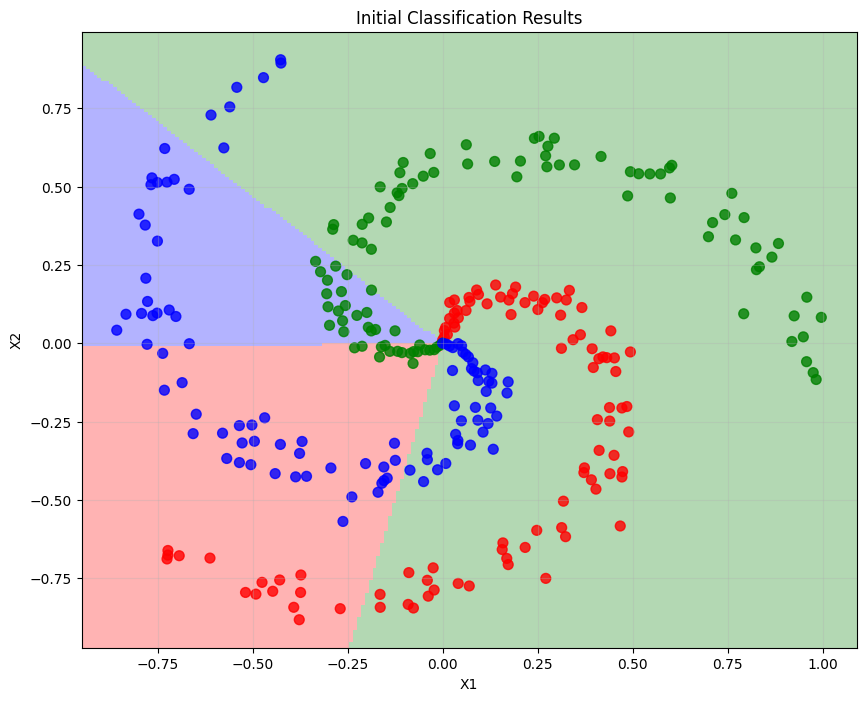

In [3]:
plot_classification_results(X, y, model, title="Initial Classification Results")
plt.show()

# Main training loop

Epoch 0: Loss = 1.0868, Accuracy = 0.0000
Epoch 200: Loss = 0.7377, Accuracy = 0.0000
Epoch 400: Loss = 0.6738, Accuracy = 0.0000
Epoch 600: Loss = 0.6290, Accuracy = 0.0000
Epoch 800: Loss = 0.5727, Accuracy = 0.0000
Epoch 1000: Loss = 0.5064, Accuracy = 0.0000
Epoch 1200: Loss = 0.4394, Accuracy = 0.0000
Epoch 1400: Loss = 0.3810, Accuracy = 0.0000
Epoch 1600: Loss = 0.3344, Accuracy = 0.0000
Epoch 1800: Loss = 0.2982, Accuracy = 0.0000
Epoch 2000: Loss = 0.2702, Accuracy = 0.0000
Epoch 2200: Loss = 0.2478, Accuracy = 0.0000
Epoch 2400: Loss = 0.2296, Accuracy = 0.0000
Epoch 2600: Loss = 0.2145, Accuracy = 0.0000
Epoch 2800: Loss = 0.2012, Accuracy = 0.0000
Epoch 3000: Loss = 0.1894, Accuracy = 0.0000
Epoch 3200: Loss = 0.1793, Accuracy = 0.0000
Epoch 3400: Loss = 0.1703, Accuracy = 0.0000
Epoch 3600: Loss = 0.1621, Accuracy = 0.0000
Epoch 3800: Loss = 0.1545, Accuracy = 0.0000
Epoch 4000: Loss = 0.1479, Accuracy = 0.0000
Epoch 4200: Loss = 0.1421, Accuracy = 0.0000
Epoch 4400: Loss 

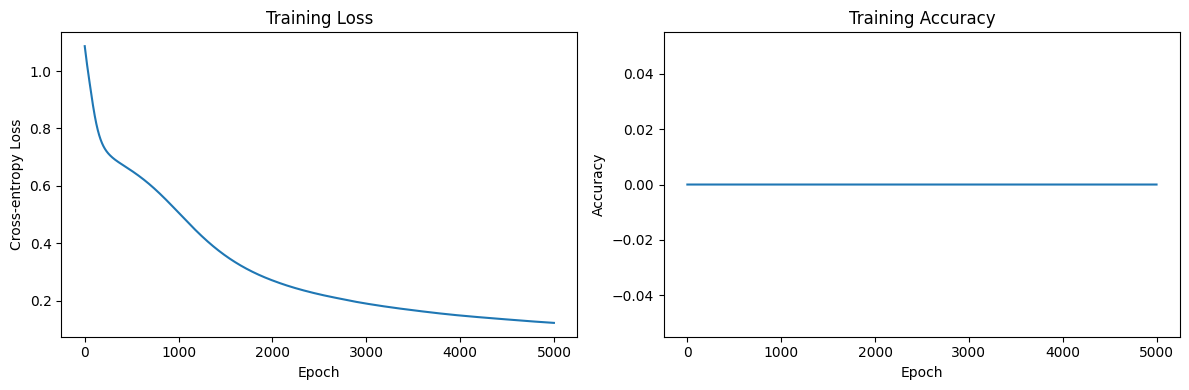

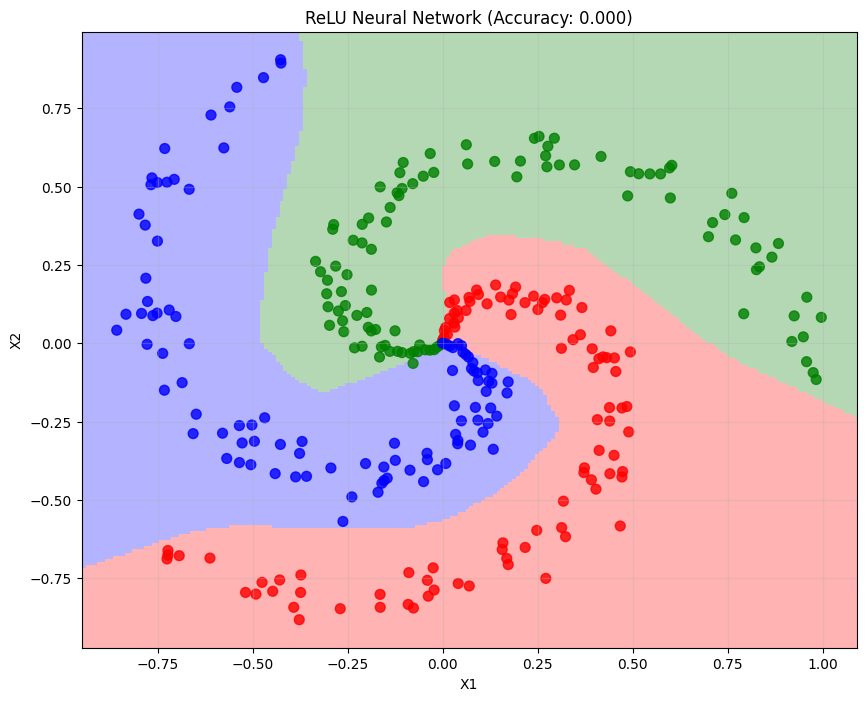

In [4]:
losses = []
accuracies = []

# Open file for gradient sanity check
gradient_file = open('my-gradient-check.txt', 'w')

for epoch in range(5000):
    m = X.shape[0]
    W_grad = np.zeros_like(model.W)
    b_grad = np.zeros_like(model.b)
    A_grad = np.zeros_like(model.A)
    
    total_loss = 0.0
    correct_predictions = 0
    
    for i in range(m): # Loop over each training sample
        # YOUR CODE HERE
        x = X[i]
        label = y[i]
        u, h, z, p = model.forward(x)

        # Compute loss (cross-entropy)
        loss = -np.log(p[label])
        total_loss += loss

        #Gradient of the loss w.r.t. z
        dLdz = p.copy()
        dLdz[label] -= 1  # dL/dz

        # Gradients for A
        dzdA = h.T 
        dLdA = np.outer(dzdA, dLdz )
        A_grad += dLdA  # dL/dA = h^T * dz

        # Gradients w.r.t. h
        dLdh = dLdz @ model.A.T # dL/dh = dz * A^T

        # Gradients w.r.t. u
        dLdu = dLdh * relu_derivative(u)  # dL/du = dL/dh * ReLU'

        # Gradients w.r.t. b
        dLdb = dLdu  # dL/db = du
        b_grad += dLdb

        # Gradients w.r.t. W
        dLdW = np.outer(x, dLdu)  # dL/dW = x^T * du
        W_grad += dLdW
        
    
        # END OF INNER FOR LOOP
        # IN YOUR SUBMISSION, YOU SHOULDN'T EDIT ANYTHING OUTSIDE THIS LOOP
    W_grad /= m
    b_grad /= m
    A_grad /= m
    
    loss = total_loss / m
    accuracy = correct_predictions / m
    
    losses.append(loss)
    accuracies.append(accuracy)

    model.W -= lr * W_grad
    model.b -= lr * b_grad
    model.A -= lr * A_grad

    ## Sanity check: print and save gradients for first 2 iterations
    ## Uncomment lines below for debugging
    # if epoch <= 1:
    #     print(f"\n=== Gradient Check: Epoch {epoch} ===")
    #     print(f"W_grad:\n{W_grad}")
    #     print(f"b_grad:\n{b_grad}")
    #     print(f"A_grad:\n{A_grad}")

    #     gradient_file.write(f"=== Gradient Check: Epoch {epoch} ===\n")
    #     gradient_file.write(f"W_grad:\n{W_grad}\n\n")
    #     gradient_file.write(f"b_grad:\n{b_grad}\n\n")
    #     gradient_file.write(f"A_grad:\n{A_grad}\n\n")
    #     gradient_file.write("\n" + "="*50 + "\n\n")
    ## End Sanity check

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {accuracy:.4f}")


gradient_file.close()

final_accuracy = accuracies[-1]
print(f"\nFinal accuracy: {final_accuracy:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy Loss')

plt.subplot(1, 2, 2)
plt.plot(accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.savefig('training_curves.pdf')

plot_classification_results(X, y, model, f"ReLU Neural Network (Accuracy: {final_accuracy:.3f})")
plt.savefig('spiral_classification.pdf')